In [5]:
!pip install pandas numpy matplotlib seaborn scikit-learn

'pip' is not recognized as an internal or external command,
operable program or batch file.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer

ModuleNotFoundError: No module named 'pandas'

In [20]:
df1 = pd.read_csv('synthetic_student_performance_hidden.csv')
df2 = pd.read_csv('student_performance_dirty.csv')

df1_dropped = df1.dropna().copy()

print(df1.shape)
print(df2.shape)

(200, 10)
(202, 6)


In [21]:
num1 = ['Age', 'HoursStudied', 'AttendanceRate', 'PreviousGrade', 'FinalExamScore']
cat1 = ['Gender', 'Subject', 'StudyMethod', 'Passed']

num2 = ['Study_Hours', 'Attendance',
        'Assignments_Score', 'Exam_Score',
        'Projects_Score']

df1[num1] = SimpleImputer(strategy='mean').fit_transform(df1[num1])
df1[cat1] = SimpleImputer(strategy='most_frequent').fit_transform(df1[cat1])

df2[num2] = SimpleImputer(strategy='mean').fit_transform(df2[num2])

print(df1.isnull().sum())
print(df2.isnull().sum())

StudentID         0
Age               0
Gender            0
Subject           0
HoursStudied      0
StudyMethod       0
AttendanceRate    0
PreviousGrade     0
FinalExamScore    0
Passed            0
dtype: int64
Study_Hours          0
Attendance           0
Assignments_Score    0
Exam_Score           0
Projects_Score       0
Major                0
dtype: int64


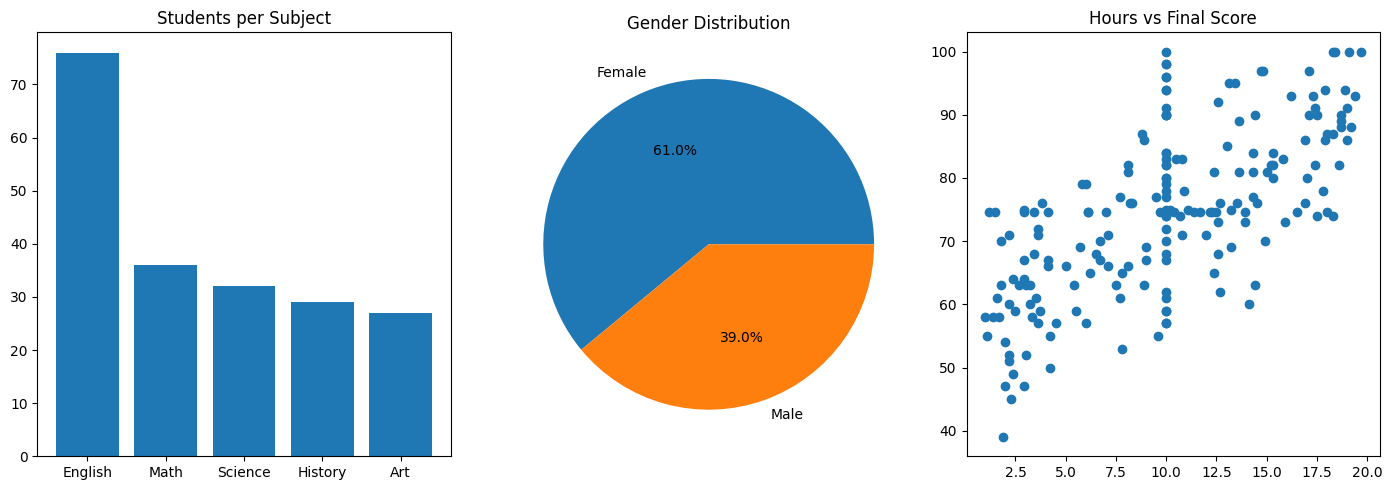

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(14,5))

s = df1['Subject'].value_counts()

axes[0].bar(s.index, s.values)
axes[0].set_title('Students per Subject')

g = df1['Gender'].value_counts()

axes[1].pie(g, labels=g.index, autopct='%1.1f%%')
axes[1].set_title('Gender Distribution')

axes[2].scatter(df1['HoursStudied'], df1['FinalExamScore'])
axes[2].set_title('Hours vs Final Score')

plt.tight_layout()
plt.show()

In [23]:
le = LabelEncoder()

for col in cat1:
    df1[col + '_enc'] = le.fit_transform(df1[col])

features = [
    'Age',
    'HoursStudied',
    'AttendanceRate',
    'PreviousGrade',
    'Gender_enc',
    'Subject_enc',
    'StudyMethod_enc'
]

print(df1.head())

      StudentID   Age  Gender  Subject  HoursStudied StudyMethod  \
0  Student_0001  18.0    Male  Science     18.600000    Tutoring   
1  Student_0002  17.0    Male  English      4.100000  Solo Study   
2  Student_0003  18.0  Female  History      9.967081  Solo Study   
3  Student_0004  18.0  Female     Math      2.900000  Solo Study   
4  Student_0005  18.0  Female  English      1.600000    Tutoring   

   AttendanceRate  PreviousGrade  FinalExamScore Passed  Gender_enc  \
0           60.60      76.676829            82.0    Yes           1   
1           79.55      76.676829            66.0    Yes           1   
2           91.60      94.000000           100.0    Yes           0   
3           93.50      71.000000            64.0    Yes           0   
4           91.30      76.676829            61.0    Yes           0   

   Subject_enc  StudyMethod_enc  Passed_enc  
0            4                3           1  
1            1                2           1  
2            2            

In [24]:
X = df1[features]
y = df1['FinalExamScore']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

models = {
    'Linear': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1)
}

results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    results[name] = {
        'preds': preds,
        'RMSE': round(np.sqrt(mean_squared_error(y_test, preds)), 2),
        'R2': round(r2_score(y_test, preds), 3)
    }


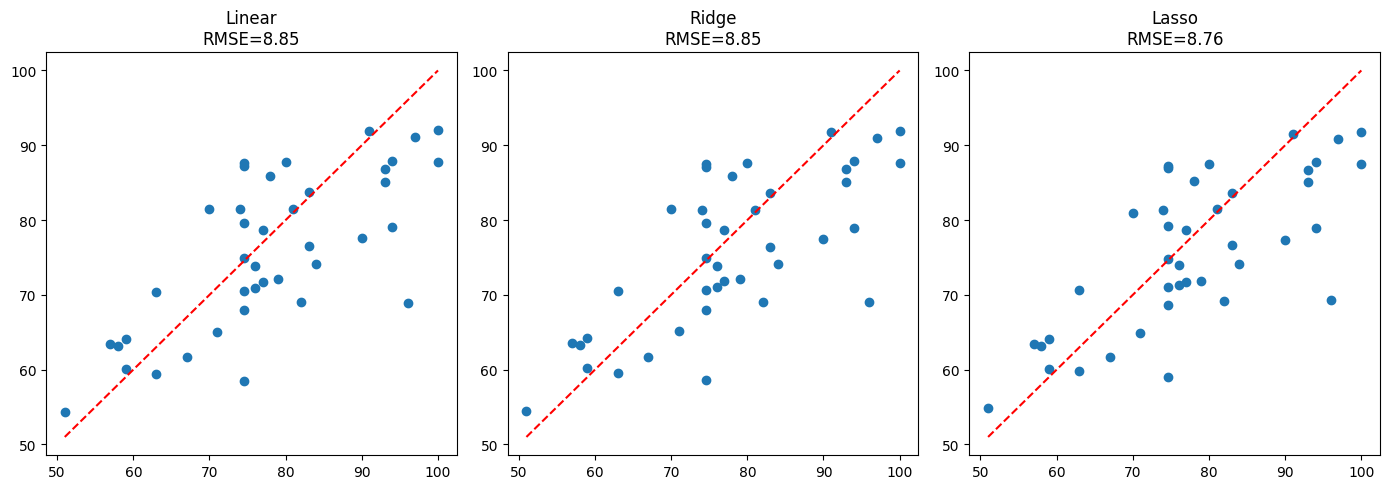

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(14,5))

for ax, (name, res) in zip(axes, results.items()):

    ax.scatter(y_test, res['preds'])

    mn = y_test.min()
    mx = y_test.max()

    ax.plot([mn, mx], [mn, mx], 'r--')

    ax.set_title(f'{name}\nRMSE={res["RMSE"]}')

plt.tight_layout()
plt.show()

In [26]:
X_clust = StandardScaler().fit_transform(df2[num2])

inertias = []

for k in range(1, 11):

    km = KMeans(n_clusters=k, random_state=42, n_init=10)

    km.fit(X_clust)

    inertias.append(km.inertia_)

optimal_k = 4

df2['Cluster'] = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
).fit_predict(X_clust)

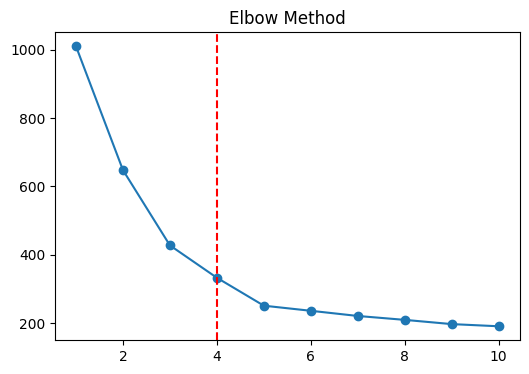

In [27]:
plt.figure(figsize=(6,4))

plt.plot(range(1,11), inertias, marker='o')

plt.axvline(x=optimal_k, color='red', linestyle='--')

plt.title('Elbow Method')

plt.show()

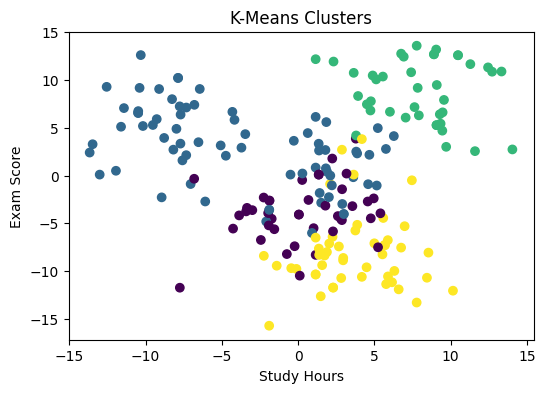

In [28]:
plt.figure(figsize=(6,4))

plt.scatter(
    df2['Study_Hours'],
    df2['Exam_Score'],
    c=df2['Cluster']
)

plt.title('K-Means Clusters')

plt.xlabel('Study Hours')
plt.ylabel('Exam Score')

plt.show()